In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sales_df = pd.read_excel(r"C:\Users\SEKAR\Desktop\Raw data\New Folder\final_uksales_data.xlsx")

In [3]:
sales_df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Quarter,Month_Name,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,4,December,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,4,December,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,4,December,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,4,December,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,4,December,Wednesday


In [9]:
sales_df.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     131418
Country             0
Revenue             0
Year                0
Quarter             0
Month_Name          0
Weekday             0
dtype: int64

In [7]:
sales_df[["Quantity","UnitPrice","Revenue"]].describe()

,Quantity,UnitPrice,Revenue
count,522557.000000,522557.000000,522557.000000
mean,10.364029,3.274936,19.169436
std,38.995857,4.396066,86.056012
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.900000
75%,12.000000,4.130000,17.700000
max,4800.000000,649.500000,38970.000000


In [10]:
sales_df.describe(include="object")

,StockCode,Description,Country,Month_Name,Weekday
count,522557,522557,522557,522557,522557
unique,3803,3845,38,12,6
top,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom,November,Thursday
freq,2320,2311,478893,81722,99760


In [11]:
sales_df.nunique()                                                                 #Check Unique Values

InvoiceNo      19773
StockCode       3803
Description     3845
Quantity         372
InvoiceDate    18332
UnitPrice        501
CustomerID      4334
Country           38
Revenue         3956
Year               2
Quarter            4
Month_Name        12
Weekday            6
dtype: int64

In [12]:
sales_df["Revenue"].describe()                                                   #Revenue Summary

count    522557.000000
mean         19.169436
std          86.056012
min           0.001000
25%           3.900000
50%           9.900000
75%          17.700000
max       38970.000000
Name: Revenue, dtype: float64

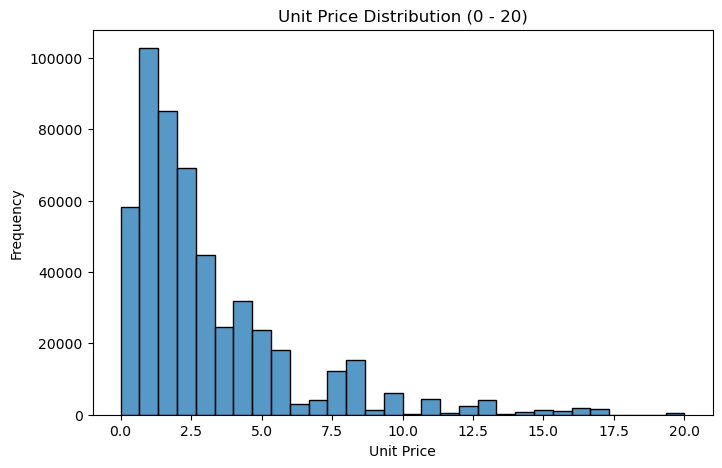

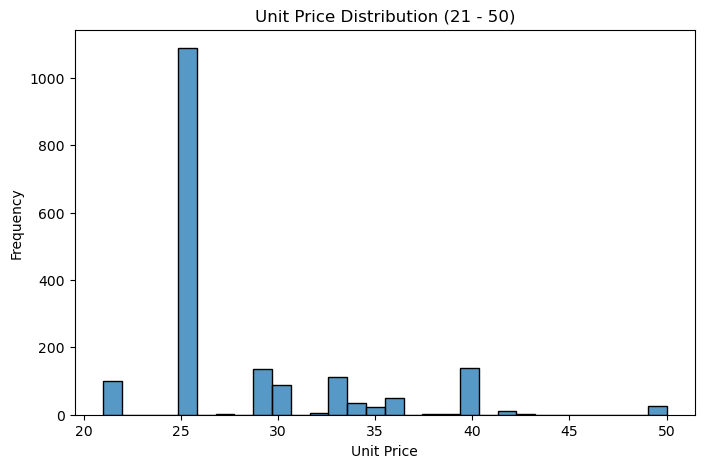

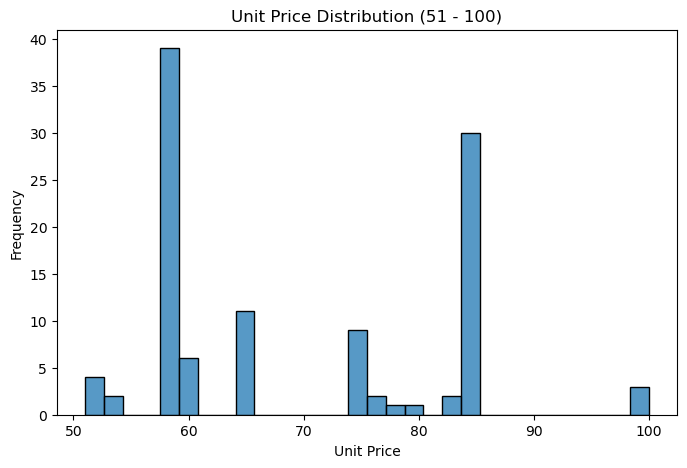

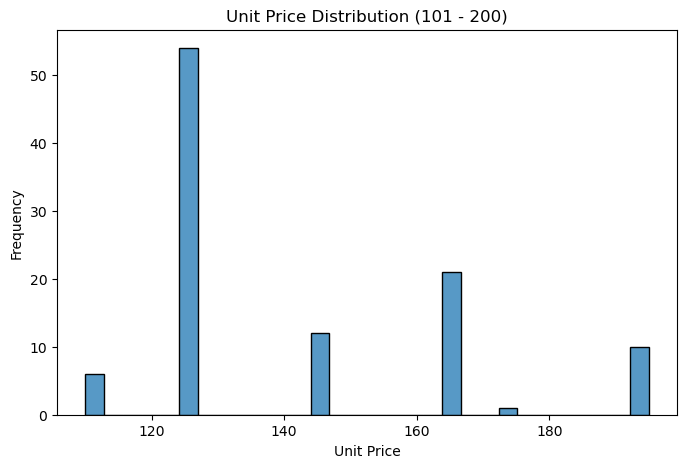

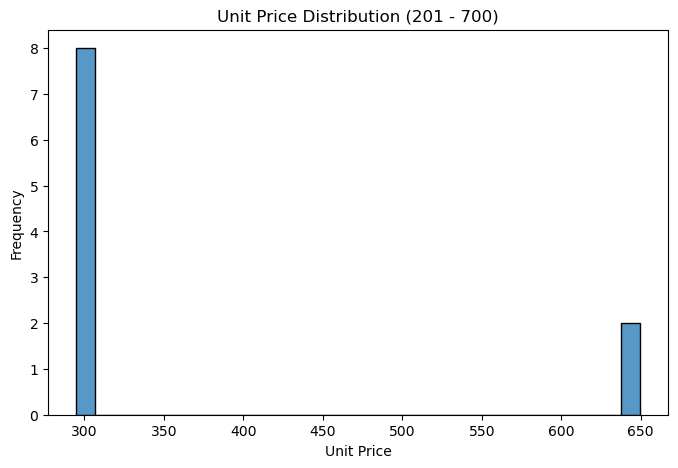

In [24]:

ranges = [(0,20), (21,50), (51,100), (101,200), (201,700)]

for start, end in ranges:
    plt.figure(figsize=(8,5))

    sns.histplot(
        sales_df[sales_df["UnitPrice"].between(start, end)]["UnitPrice"],
        bins=30
    )

    plt.title(f"Unit Price Distribution ({start} - {end})")
    plt.xlabel("Unit Price")
    plt.ylabel("Frequency")

    plt.show()

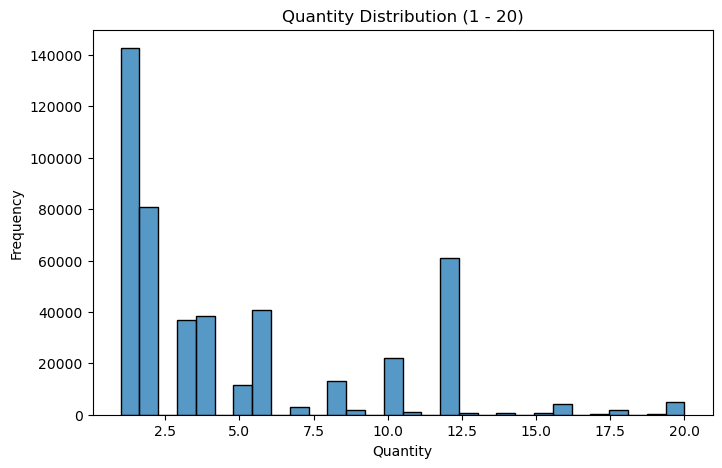

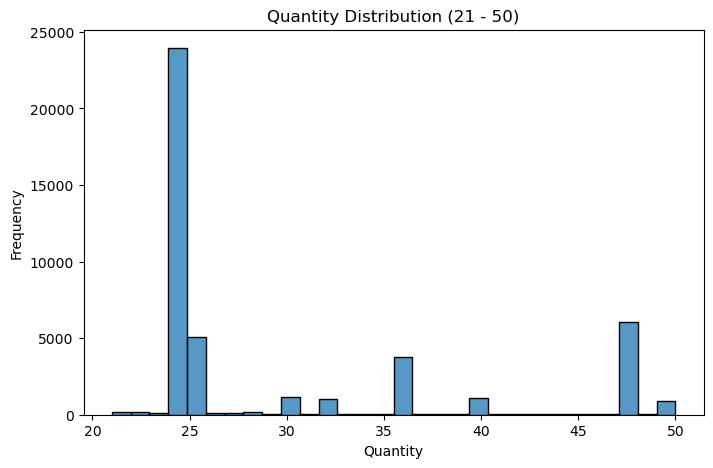

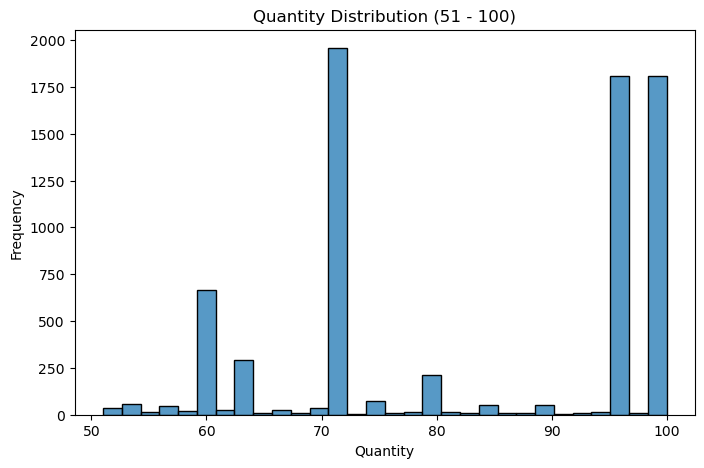

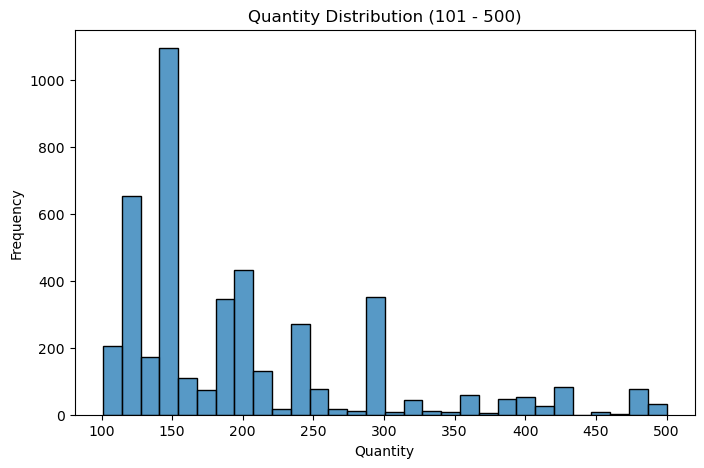

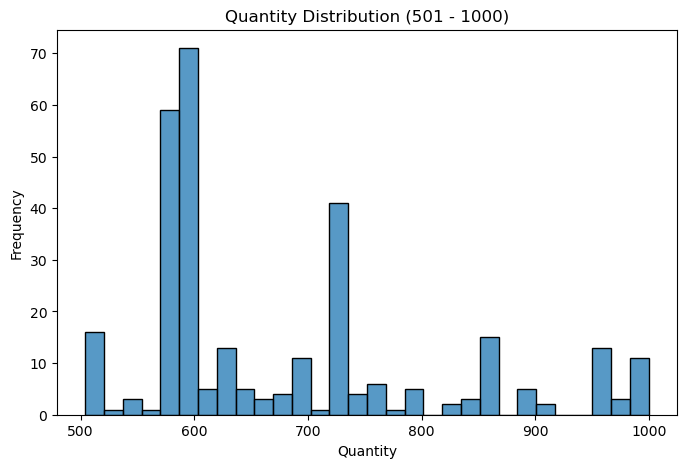

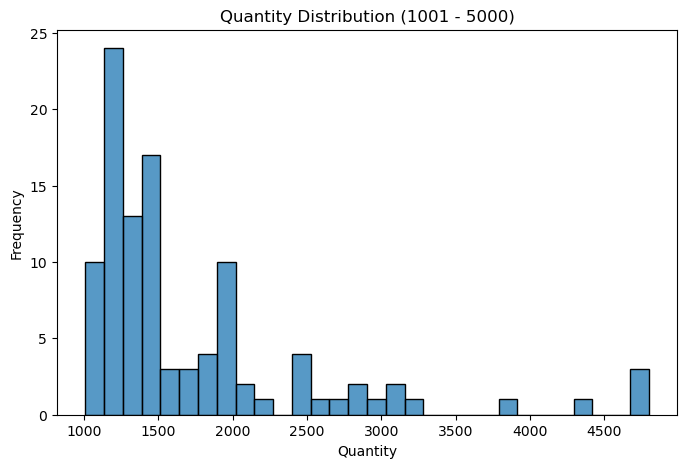

In [26]:
ranges = [
    (1, 20),
    (21, 50),
    (51, 100),
    (101, 500),
    (501, 1000),
    (1001, 5000)
]

for start, end in ranges:
    plt.figure(figsize=(8,5))

    sns.histplot(
        sales_df[sales_df["Quantity"].between(start, end)]["Quantity"],
        bins=30
    )

    plt.title(f"Quantity Distribution ({start} - {int(end)})")
    plt.xlabel("Quantity")
    plt.ylabel("Frequency")

    plt.show()

In [15]:
sales_df["Revenue"].sum()                                    #total revenue----------------------- #Business KPIs

np.float64(10017122.933)

In [28]:
 sales_df["InvoiceNo"].nunique()                            #total orders----------------------- #Business KPIs

19773

In [29]:
sales_df["CustomerID"].nunique()                          #total customers----------------------- #Business KPIs

4334

In [30]:
sales_df["Quantity"].sum()                          #total product sold----------------------- #Business KPIs

np.int64(5415796)

In [17]:
sales_df.groupby("InvoiceNo")["Revenue"].sum().mean()   #Average Order Value---------------------- #Business KPIs

np.float64(506.6061261821676)

In [31]:
sales_df.groupby("InvoiceNo")["Quantity"].sum().mean() #Average Quantity per Order---------------- #Business KPIs

np.float64(273.89854852576747)

In [8]:
# Country Analysis
#1. Revenue

country_revenue = sales_df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
country_revenue

Country
United Kingdom          8494362.283
Netherlands              283889.340
Ireland                  270843.360
Germany                  205381.150
France                   184485.500
Australia                138103.810
Spain                     55706.560
Switzerland               53065.600
Japan                     37416.370
Belgium                   36927.340
Sweden                    36828.830
Norway                    32454.640
Portugal                  26951.110
Channel Islands           19997.540
Finland                   18344.880
Denmark                   18211.340
Italy                     15820.240
Cyprus                    13167.160
Hong Kong                  9744.190
Singapore                  9120.390
Austria                    8742.680
Israel                     8129.410
Poland                     6974.650
Unspecified                4740.940
Greece                     4425.520
Iceland                    4310.000
USA                        3580.390
Canada              

In [9]:
# Country Analysis
#2. orders
country_orders = sales_df.groupby("Country")["InvoiceNo"].nunique().sort_values(ascending= False)
country_orders

Country
United Kingdom          17901
Germany                   443
France                    382
Ireland                   282
Belgium                    98
Netherlands                93
Spain                      88
Australia                  56
Switzerland                50
Portugal                   50
Finland                    40
Italy                      35
Sweden                     34
Norway                     32
Channel Islands            25
Japan                      19
Poland                     19
Denmark                    18
Austria                    17
Cyprus                     14
Unspecified                13
Israel                      8
Iceland                     7
Hong Kong                   7
Canada                      5
Malta                       5
USA                         5
Greece                      5
Singapore                   4
Lithuania                   4
Bahrain                     3
European Community          3
United Arab Emirates        2
Cz

In [10]:
# Country Analysis
#3. Customers
country_customers = sales_df.groupby("Country")["CustomerID"].nunique().sort_values(ascending=False)

country_customers

Country
United Kingdom          3916
Germany                   94
France                    87
Spain                     30
Belgium                   25
Switzerland               21
Portugal                  19
Italy                     14
Finland                   12
Austria                   11
Norway                    10
Netherlands                9
Australia                  9
Channel Islands            9
Denmark                    9
Cyprus                     8
Sweden                     8
Japan                      8
Poland                     6
Greece                     4
USA                        4
Canada                     4
Unspecified                4
Israel                     3
Ireland                    3
Malta                      2
United Arab Emirates       2
Bahrain                    2
Czech Republic             1
Lithuania                  1
Lebanon                    1
Saudi Arabia               1
Singapore                  1
South Africa               1
Icelan

In [11]:
monthly_sales = sales_df.groupby("Month_Name")["Revenue"].sum().sort_values(ascending=False)                 #monthly revenue

monthly_sales

Month_Name
November     1452078.480
December     1231721.100
October      1103323.420
September    1028307.881
May           740036.330
June          737683.990
August        724300.660
March         689841.840
July          688245.171
January       598247.860
April         515469.661
February      507866.540
Name: Revenue, dtype: float64

In [12]:
quarter_sales = sales_df.groupby("Quarter")["Revenue"].sum().sort_values(ascending=False)                      #Quarterly Revenue

quarter_sales

Quarter
4    3787123.000
3    2440853.712
2    1993189.981
1    1795956.240
Name: Revenue, dtype: float64

In [13]:
weekday_sales = sales_df.groupby("Weekday")["Revenue"].sum().sort_values(ascending=False)        #Weekday Revenue

weekday_sales

Weekday
Thursday     2131718.100
Tuesday      2012901.221
Wednesday    1782428.380
Monday       1683019.560
Friday       1608744.171
Sunday        798311.501
Name: Revenue, dtype: float64

In [14]:
                           #Top 10 Products by Revenue

top_productsales = sales_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False)
top_productsales.head(10)

Description
REGENCY CAKESTAND 3 TIER              174156.54
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
CHILLI LIGHTS                          54096.36
SPOTTY BUNTING                         43148.18
JUMBO BAG PINK POLKADOT                42401.01
Name: Revenue, dtype: float64

In [47]:
                                 #Bottom 10 Products by Revenue 

least_productsales = sales_df.groupby("Description")["Revenue"].sum().sort_values(ascending=False)
least_productsales.tail(10)


Description
PACK 4 FLOWER/BUTTERFLY PATCHES        1.250
ORANGE FELT VASE + FLOWERS             1.250
WIRE FLOWER T-LIGHT HOLDER             1.250
60 GOLD AND SILVER FAIRY CAKE CASES    1.100
CAT WITH SUNGLASSES BLANK CARD         0.950
HAPPY BIRTHDAY CARD TEDDY/CAKE         0.950
PINK CRYSTAL GUITAR PHONE CHARM        0.850
VINTAGE BLUE TINSEL REEL               0.840
HEN HOUSE W CHICK IN NEST              0.420
PADS TO MATCH ALL CUSHIONS             0.003
Name: Revenue, dtype: float64

In [48]:
                                        #Top 10 Products by Quantity

top_productquantity = sales_df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)
top_productquantity.head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
PACK OF 12 LONDON TISSUES             26119
PACK OF 60 PINK PAISLEY CAKE CASES    24820
Name: Quantity, dtype: int64

In [51]:
                            # expensive product
sales_df.groupby("Description")["UnitPrice"].max().sort_values(ascending=False).head(10)

Description
PICNIC BASKET WICKER 60 PIECES       649.50
VINTAGE RED KITCHEN CABINET          295.00
VINTAGE BLUE KITCHEN CABINET         295.00
LOVE SEAT ANTIQUE WHITE METAL        195.00
REGENCY MIRROR WITH SHUTTERS         165.00
RUSTIC SEVENTEEN DRAWER SIDEBOARD    165.00
CHEST NATURAL WOOD 20 DRAWERS        125.00
HALL CABINET WITH 3 DRAWERS          100.00
CINDERELLA CHANDELIER                 99.96
SWEETHEART CREAM STEEL TABLE RECT     99.96
Name: UnitPrice, dtype: float64

In [57]:
                            # cheap product
sales_df.groupby("Description")["UnitPrice"].max().sort_values(ascending=True).head(10)

Description
PADS TO MATCH ALL CUSHIONS             0.001
WRAP BAD HAIR DAY                      0.100
POPART WOODEN PENCILS ASST             0.120
POP ART PUSH DOWN RUBBER               0.120
MINI HIGHLIGHTER PENS                  0.120
FOLDING CAMPING SCISSOR W/KNIF & S     0.120
ROUND BLUE CLOCK WITH SUCKER           0.190
GOLD PRINT PAPER BAG                   0.190
ROUND ARTICULATED PINK CLOCK W/SUCK    0.190
ASSORTED COLOUR SUCTION CUP HOOK       0.190
Name: UnitPrice, dtype: float64

In [62]:
                                   # Customers with Most Orders
sales_df.groupby("CustomerID")["InvoiceNo"].nunique().sort_values(ascending=False).head(10)

CustomerID
12748.0    206
14911.0    198
17841.0    124
13089.0     97
15311.0     91
14606.0     90
12971.0     86
14646.0     72
13408.0     62
16029.0     62
Name: InvoiceNo, dtype: int64

In [63]:
                                   #Customer Average Spend
sales_df.groupby("CustomerID")["Revenue"].mean().sort_values(ascending=False).head(10)

CustomerID
15098.0    13305.500000
12346.0     4992.000000
15749.0     4453.430000
15195.0     3861.000000
16446.0     3328.966667
18087.0     3202.920000
13135.0     3096.000000
16532.0     1687.200000
16000.0     1377.077778
16754.0     1001.200000
Name: Revenue, dtype: float64

In [64]:
sales_df[["Quantity","UnitPrice","Revenue"]].corr()                      # checking correlation

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.086171,0.529174
UnitPrice,-0.086171,1.000000,0.194012
Revenue,0.529174,0.194012,1.000000


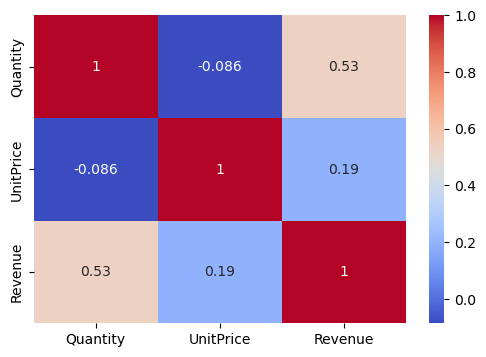

In [65]:
plt.figure(figsize=(6,4))

sns.heatmap(
    sales_df[["Quantity","UnitPrice","Revenue"]].corr(),
    annot=True,                                                               # Quantity and revenue has medium relationship
    cmap="coolwarm"
)

plt.show()                                                                             

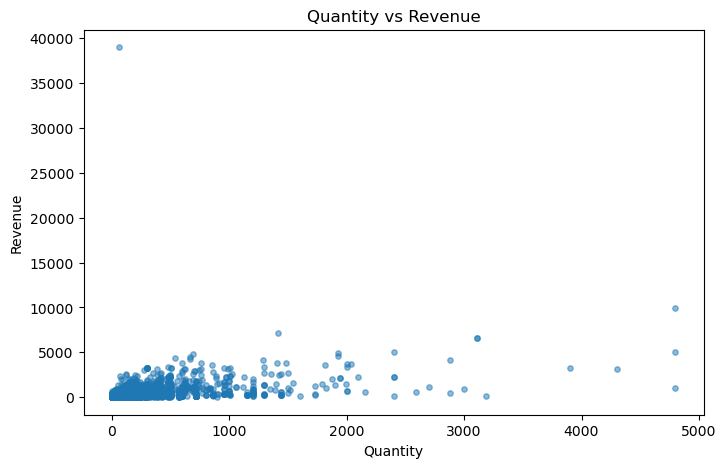

In [5]:
plt.figure(figsize=(8,5))

plt.scatter(
    sales_df["Quantity"],
    sales_df["Revenue"],
    s=15,
    alpha=0.5                                                                 #  Scatter plot (Quantity vs Revenue)
)

plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.title("Quantity vs Revenue")

plt.show()

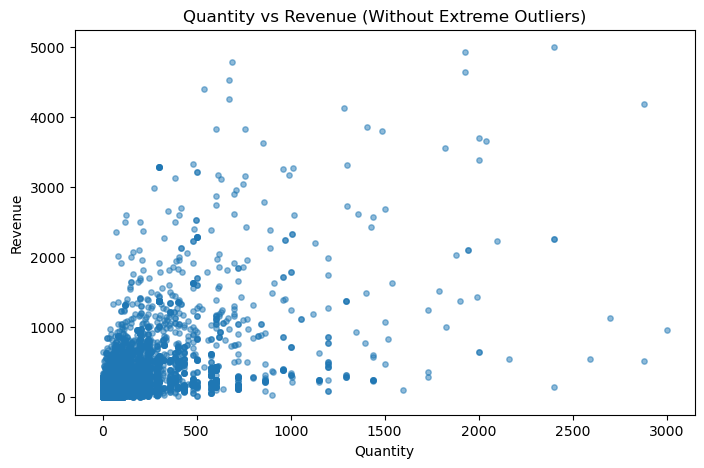

In [6]:
plot_df = sales_df[
    (sales_df["Quantity"] <= 3000) &
    (sales_df["Revenue"] <= 5000)
]

plt.figure(figsize=(8,5))
plt.scatter(plot_df["Quantity"], plot_df["Revenue"], s=15, alpha=0.5)

plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.title("Quantity vs Revenue (Without Extreme Outliers)")
plt.show()

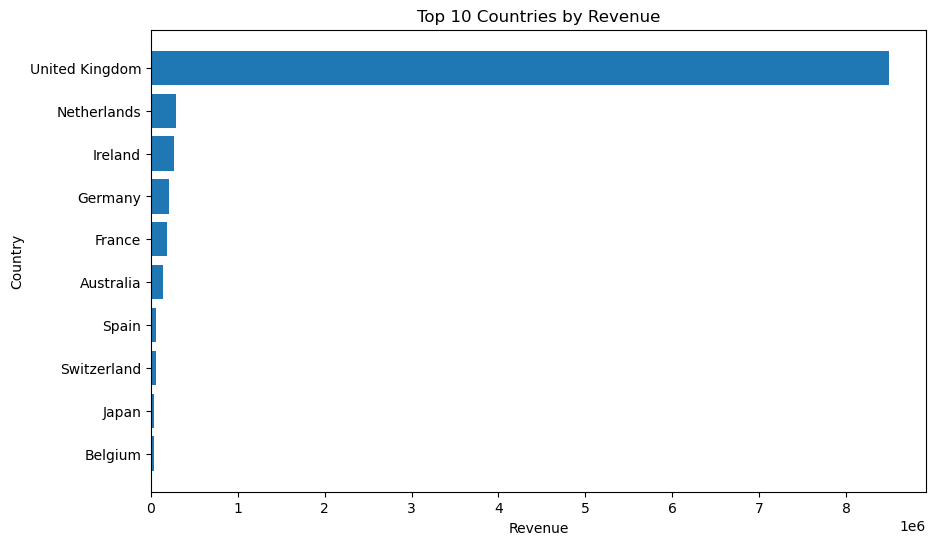

In [16]:
top10 = (
    sales_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
                                                                               # Country-wise Revenue Chart
plt.barh(top10.index[::-1], top10.values[::-1])                

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.show()

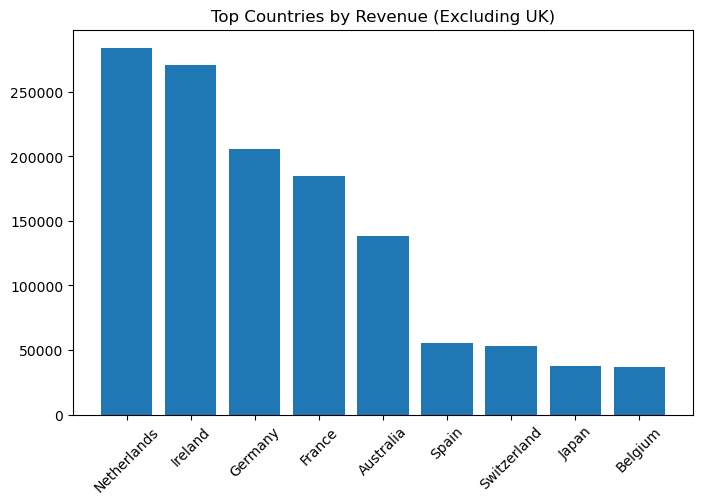

In [17]:
top_without_uk = (
    top10[top10.index != "United Kingdom"]
)

plt.figure(figsize=(8,5))
plt.bar(top_without_uk.index, top_without_uk.values)

plt.xticks(rotation=45)

plt.title("Top Countries by Revenue (Excluding UK)")
plt.show()

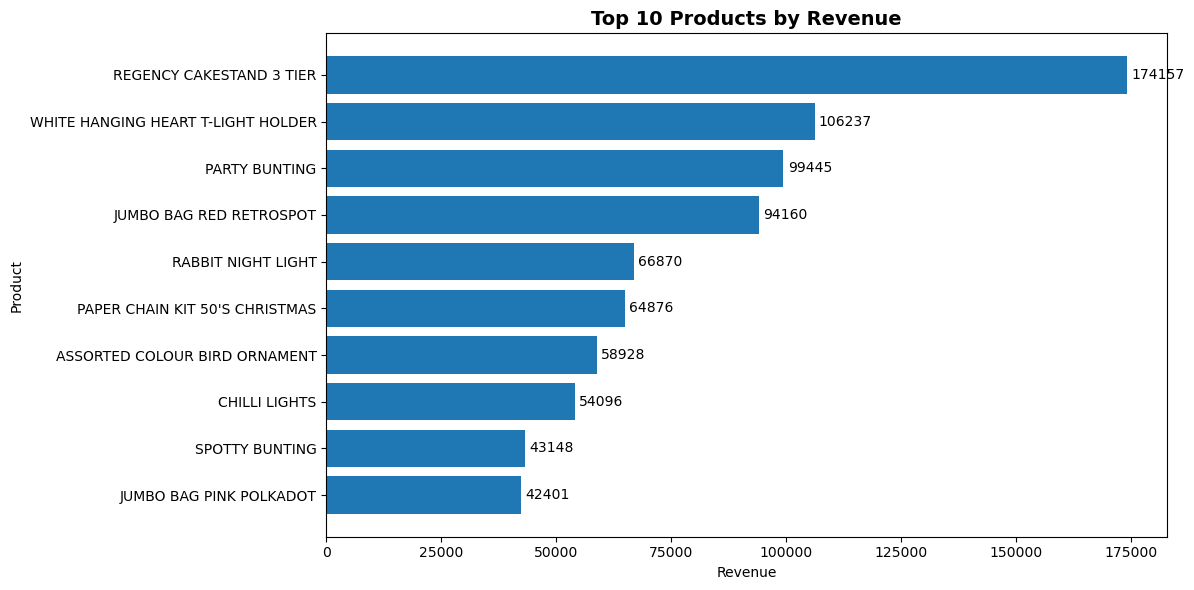

In [19]:
                                                                # Top 10 Products by Revenue

top10_products = (
    sales_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

bars = plt.barh(
    top10_products.index[::-1],      # Highest revenue at the top
    top10_products.values[::-1]
)

# Add revenue values at the end of each bar
plt.bar_label(bars, fmt="%.0f", padding=3)

plt.title("Top 10 Products by Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

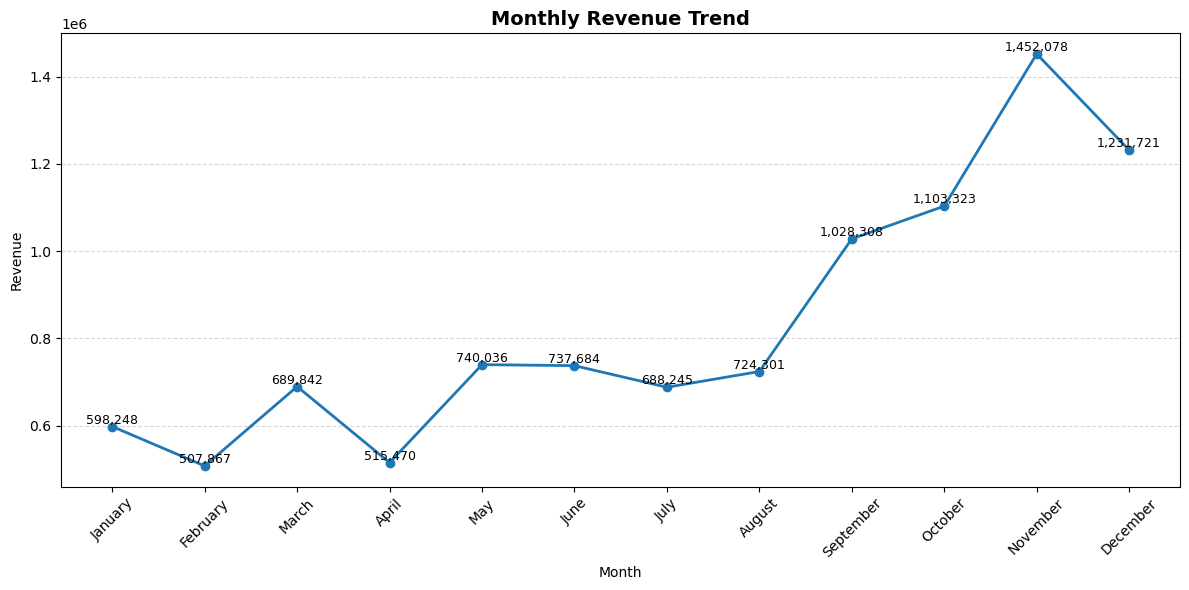

In [22]:
# Calendar month order
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

# Monthly revenue in calendar order
monthly_revenue = (
    sales_df.groupby("Month_Name")["Revenue"]
    .sum()
    .reindex(month_order)
)

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue")

# Add revenue values on each point
for x, y in zip(monthly_revenue.index, monthly_revenue.values):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
                                               # INVESTIGATING THE CANACELLED ORDERS

In [2]:
return_df = pd.read_excel(r"C:\Users\SEKAR\Desktop\Raw data\New Folder\Cancelled_Orders.xlsx")
return_df.shape

(9251, 8)

In [3]:
return_df["Description"].nunique()

1972

In [4]:
return_df.isna().sum()

InvoiceNo        0
StockCode        0
Description      0
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID     379
Country          0
dtype: int64

In [5]:
return_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9251 entries, 0 to 9250
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    9251 non-null   object        
 1   StockCode    9251 non-null   object        
 2   Description  9251 non-null   object        
 3   Quantity     9251 non-null   int64         
 4   InvoiceDate  9251 non-null   datetime64[ns]
 5   UnitPrice    9251 non-null   float64       
 6   CustomerID   8872 non-null   float64       
 7   Country      9251 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 578.3+ KB


In [6]:
return_df["InvoiceNo"].nunique()

3836

In [7]:
return_df.loc[
    return_df["Description"].str.len() < 16,
    "Description"
].drop_duplicates().sort_values()

159          AMAZON FEE
244           BINGO SET
2926    BLUE  TILE HOOK
1891    BLUE TILED TRAY
101         BUTTON BOX 
154        Bank Charges
760            CARRIAGE
798       CHILLI LIGHTS
5702    CRUK Commission
7189    DAISY HAIR BAND
7190    DAISY HAIR COMB
2514     DOORMAT HEARTS
520     DOORMAT TOPIARY
1368     DOTCOM POSTAGE
0              Discount
871       FIRST AID TIN
788     FLAMINGO LIGHTS
1065        FROG CANDLE
2227     FUNKY DIVA PEN
4997     GLAMOROUS  MUG
887      JUMBO BAG OWLS
3863    JUMBO BAG PEARS
365     JUMBO BAG TOYS 
4003     KEY FOB , SHED
8051    MILK MAIDS MUG 
1646     MIRROR CORNICE
174              Manual
5554     PACKING CHARGE
1926      PARTY BUNTING
854       PINK DOG BOWL
4348    PINK PARTY BAGS
4223     POPCORN HOLDER
144             POSTAGE
467       POTTERING MUG
252      RETRO MOD TRAY
238      RETROSPOT LAMP
155             SAMPLES
4961     SANDALWOOD FAN
5769    SHOE SHINE BOX 
6252    SPACEBOY BEAKER
3522     SPOTTY BUNTING
4914      TOYBOX

In [9]:
return_df.shape

(9251, 8)

In [8]:
financial_items = [
    "AMAZON FEE",
    "Bank Charges",
    "CARRIAGE",
    "CRUK Commission",
    "DOTCOM POSTAGE",
    "Discount",
    "PACKING CHARGE",
    "POSTAGE"
]

In [9]:
operational_items = [
    "Manual",
    "SAMPLES"
]

In [10]:
# Financial data
cancel_financial_df = return_df[
    return_df["Description"].isin(financial_items)
].copy()

# Operational data
cancel_operational_df = return_df[
    return_df["Description"].isin(operational_items)
].copy()

# Remaining cancelled products
cancel_product_df = return_df[
    ~return_df["Description"].isin(financial_items + operational_items)
].copy()

print(cancel_financial_df.shape)
print(cancel_operational_df.shape)
print(cancel_product_df.shape)

(281, 8)
(304, 8)
(8666, 8)


In [11]:
with pd.ExcelWriter("Cancelled_Order_Categorization.xlsx", engine="openpyxl") as writer:

    cancel_product_df.to_excel(
        writer,
        sheet_name="Cancelled_Products",
        index=False
    )

    cancel_financial_df.to_excel(
        writer,
        sheet_name="Financial_Items",
        index=False
    )

    cancel_operational_df.to_excel(
        writer,
        sheet_name="Operational_Items",
        index=False
    )

print("File saved successfully.")

File saved successfully.


In [12]:
cancel_product_df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
2,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
3,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
4,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
5,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
6,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
7,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
8,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
9,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom
10,C536543,22632,HAND WARMER RED RETROSPOT,-1,2010-12-01 14:30:00,2.10,17841.0,United Kingdom


In [16]:
cancel_product_df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [18]:
cancel_product_df["CustomerID"] = cancel_product_df["CustomerID"].astype("Int64")

In [19]:
cancel_product_df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              Int64
Country                object
dtype: object

In [21]:
cancel_product_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,8666.000000,8666,8666.000000,8504.0
mean,-31.157974,2011-06-26 08:59:52.245557504,4.415378,14995.161689
min,-80995.000000,2010-12-01 09:49:00,0.030000,12346.0
25%,-6.000000,2011-03-21 16:15:00,1.450000,13523.0
50%,-2.000000,2011-07-08 13:37:00,2.550000,14901.0
75%,-1.000000,2011-10-06 20:36:00,4.950000,16393.0
max,-1.000000,2011-12-09 11:58:00,295.000000,18282.0
std,1185.954020,NaN,9.132827,1705.994693


In [22]:
cancel_product_df.describe(include="object")

,InvoiceNo,StockCode,Description,Country
count,8666,8666,8666,8666
unique,3421,1937,1962,28
top,C570867,22423,REGENCY CAKESTAND 3 TIER,United Kingdom
freq,101,180,180,7328


In [23]:
country_cancel = (
    cancel_product_df["Country"]
    .value_counts()                                                                      #Cancellation by Country
    .head(10)
)

country_cancel

Country
United Kingdom    7328
Germany            437
EIRE               290
France             133
USA                112
Australia           73
Spain               45
Italy               42
Belgium             36
Japan               34
Name: count, dtype: int64

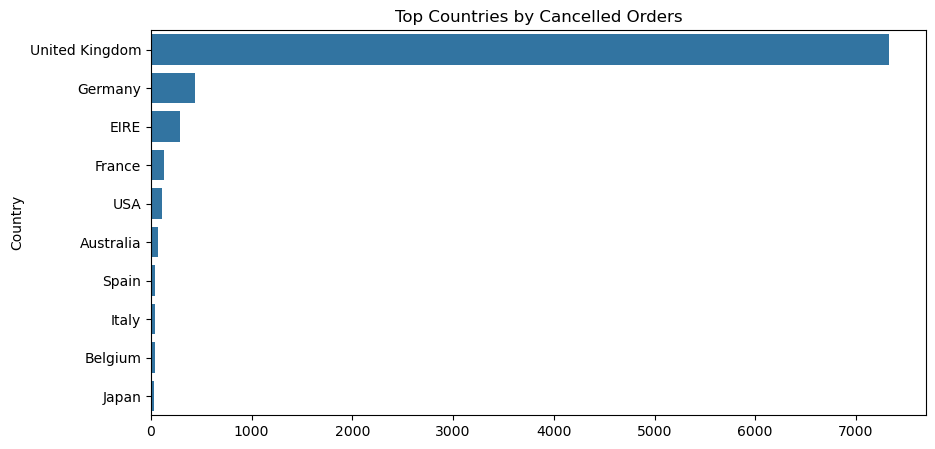

In [24]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=country_cancel.values,
    y=country_cancel.index
)

plt.title("Top Countries by Cancelled Orders")

plt.show()

In [25]:
top_products = (
    cancel_product_df["Description"]
    .value_counts()
    .head(20)
)
                                                                                          #Most Cancelled Products
top_products

Description
REGENCY CAKESTAND 3 TIER               180
JAM MAKING SET WITH JARS                87
SET OF 3 CAKE TINS PANTRY DESIGN        73
STRAWBERRY CERAMIC TRINKET BOX          54
ROSES REGENCY TEACUP AND SAUCER         54
RECIPE BOX PANTRY YELLOW DESIGN         47
JUMBO BAG RED RETROSPOT                 44
LUNCH BAG RED RETROSPOT                 44
WHITE HANGING HEART T-LIGHT HOLDER      42
GREEN REGENCY TEACUP AND SAUCER         42
WOOD 2 DRAWER CABINET WHITE FINISH      42
RED RETROSPOT CAKE STAND                42
SMALL GLASS HEART TRINKET POT           40
SET OF 3 REGENCY CAKE TINS              37
POPCORN HOLDER                          36
SET OF TEA COFFEE SUGAR TINS PANTRY     35
SILVER HANGING T-LIGHT HOLDER           35
PINK REGENCY TEACUP AND SAUCER          35
CLASSIC GLASS COOKIE JAR                34
SET/5 RED RETROSPOT LID GLASS BOWLS     34
Name: count, dtype: int64

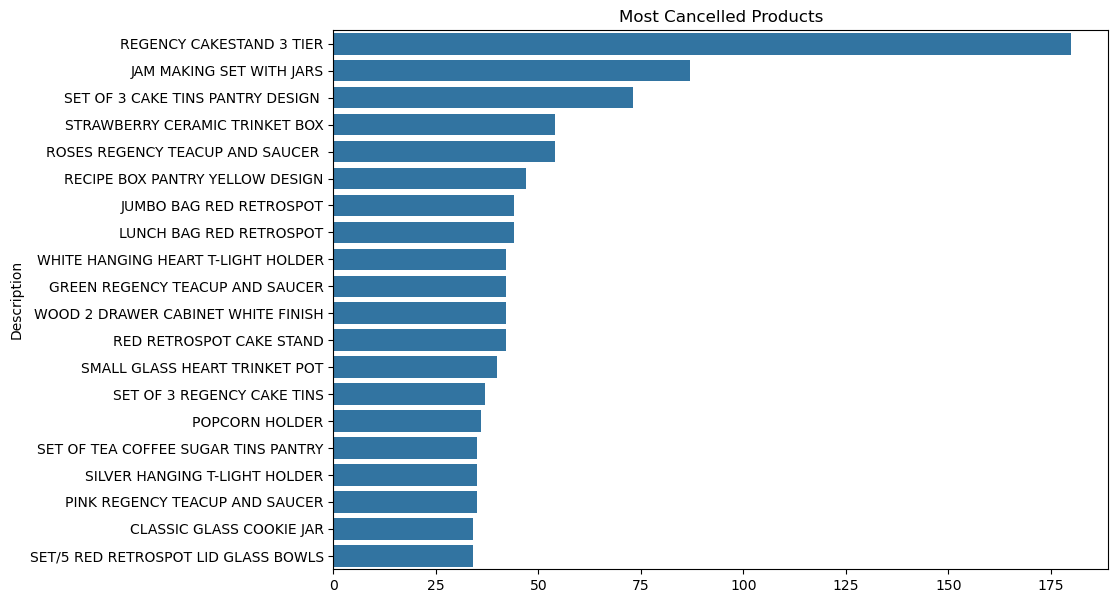

In [26]:
plt.figure(figsize=(10,7))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Most Cancelled Products")

plt.show()

In [28]:
cancel_product_df["Month"] = cancel_product_df["InvoiceDate"].dt.month_name()            #Cancellation by Month

In [29]:
month_cancel = cancel_product_df["Month"].value_counts()
                                                                                           #Cancellation by Month
month_cancel

Month
October      1119
December     1036
November     1013
September     756
January       678
June          667
July          641
March         639
August        615
May           558
April         530
February      414
Name: count, dtype: int64

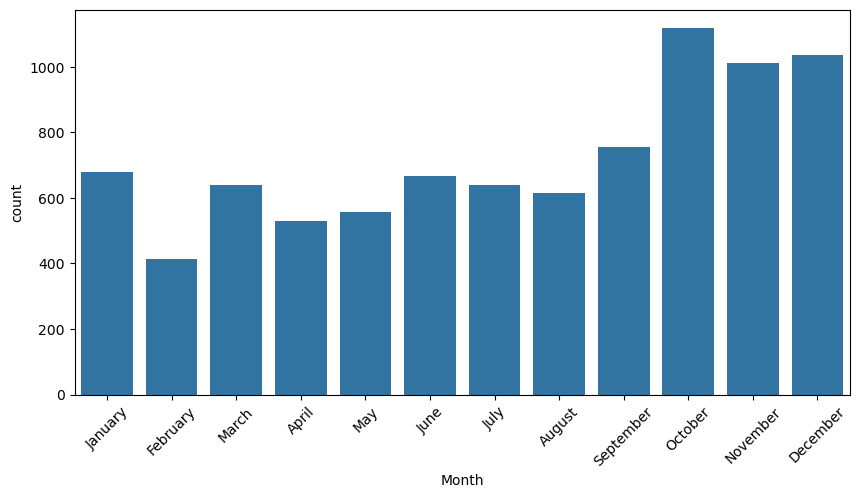

In [31]:
order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

plt.figure(figsize=(10,5))

sns.countplot(
    data=cancel_product_df,
    x="Month",
    order=order
)

plt.xticks(rotation=45)

plt.show()

In [34]:

                                          # Top Customers by Cancellation

cancel_product_df.groupby("CustomerID")["InvoiceNo"].nunique().sort_values(ascending=False).head(20)                                                                         


CustomerID
17841    45
14911    43
14606    35
15311    27
13089    21
12471    18
13534    18
13078    17
13767    15
13113    15
17511    14
12921    13
13098    13
17677    13
16133    13
13408    13
13599    12
18223    12
15189    12
17811    12
Name: InvoiceNo, dtype: int64

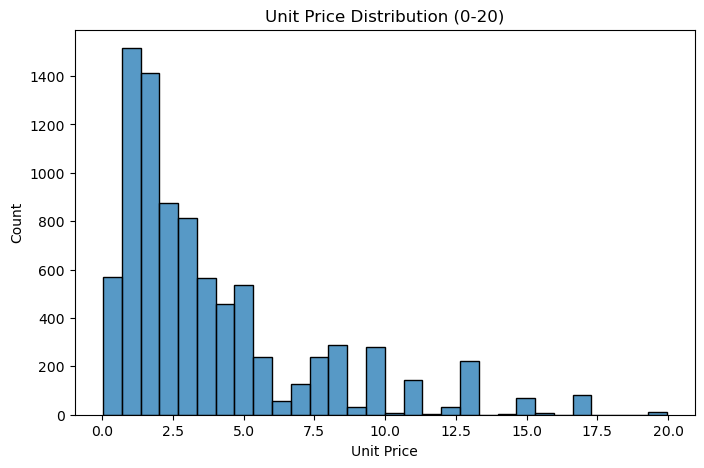

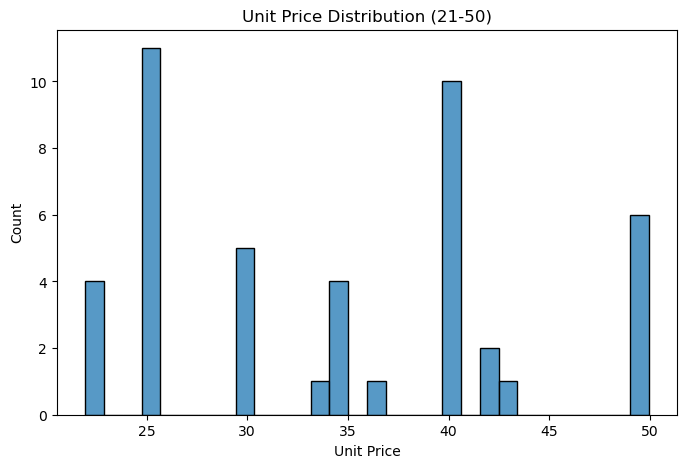

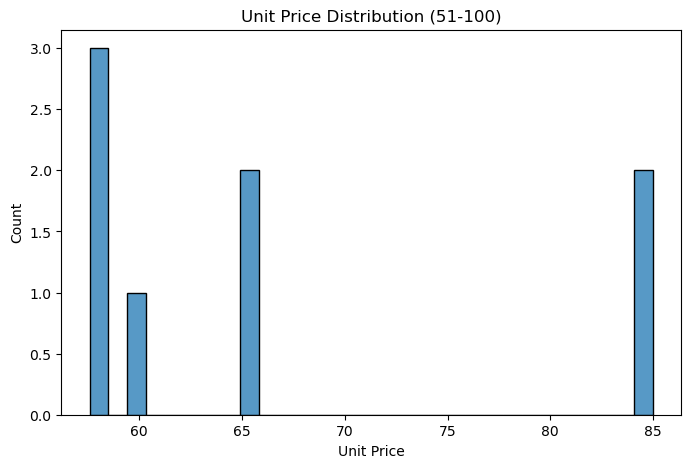

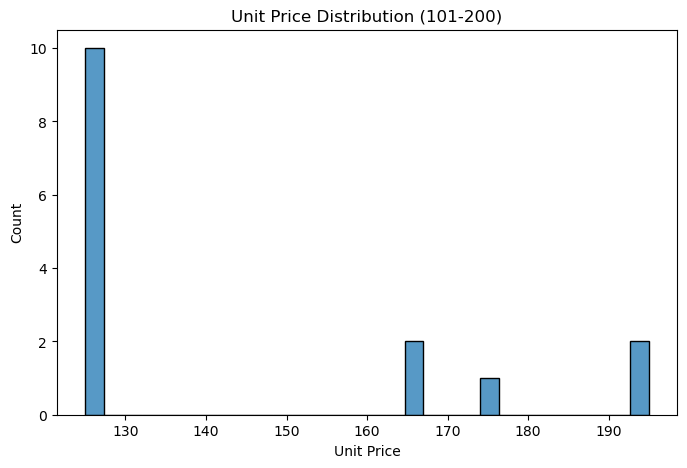

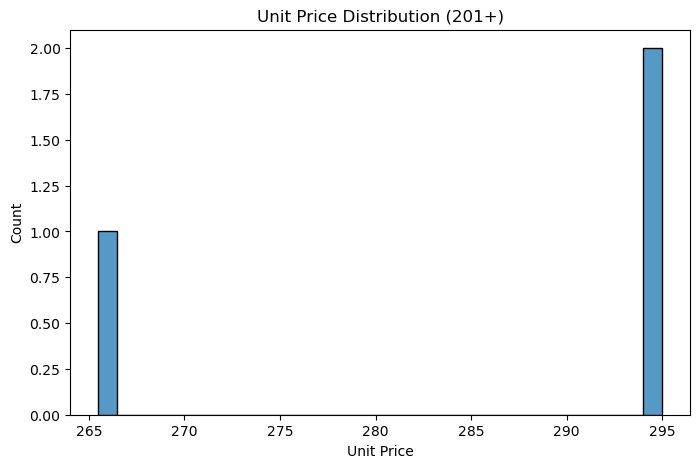

In [36]:
ranges = [(0,20), (21,50), (51,100), (101,200), (201,None)]

for start, end in ranges:

    plt.figure(figsize=(8,5))

    if end is None:                                                                                      # Unit Price Distribution
        data = cancel_product_df[
            cancel_product_df["UnitPrice"] >= start
        ]["UnitPrice"]
        title = f"Unit Price Distribution ({start}+)"
    else:
        data = cancel_product_df[
            cancel_product_df["UnitPrice"].between(start, end)
        ]["UnitPrice"]
        title = f"Unit Price Distribution ({start}-{end})"

    sns.histplot(data, bins=30)

    plt.title(title)
    plt.xlabel("Unit Price")
    plt.ylabel("Count")

    plt.show()

In [37]:
cancel_product_df["Revenue"] = (
    cancel_product_df["Quantity"] *
    cancel_product_df["UnitPrice"]
)

In [38]:
cancel_product_df["Revenue"].sum()                                                   # Revenue Lost

np.float64(-475886.16000000003)

In [42]:
cancel_product_df.groupby("Description")["Revenue"].sum().sort_values(ascending=True).head(20)  # Top cancelled revenue products

Description
PAPER CRAFT , LITTLE BIRDIE          -168469.60
MEDIUM CERAMIC TOP STORAGE JAR        -77479.64
REGENCY CAKESTAND 3 TIER               -9697.05
WHITE HANGING HEART T-LIGHT HOLDER     -6624.30
FAIRY CAKE FLANNEL ASSORTED COLOUR     -6591.42
PANTRY CHOPPING BOARD                  -4803.06
DOORMAT FAIRY CAKE                     -4554.90
GIN + TONIC DIET METAL SIGN            -3775.33
TEA TIME PARTY BUNTING                 -3692.95
FELTCRAFT DOLL MOLLY                   -3512.65
COLOUR GLASS. STAR T-LIGHT HOLDER      -3246.16
IVORY DINER WALL CLOCK                 -2653.70
RED RETROSPOT CAKE STAND               -2480.50
JUMBO BAG RED RETROSPOT                -1984.02
FLOWERS CHANDELIER T-LIGHT HOLDER      -1859.07
VINTAGE RED KITCHEN CABINET            -1730.50
ROUND SNACK BOXES SET OF 4 FRUITS      -1691.50
HOT WATER BOTTLE I AM SO POORLY        -1679.70
3 TIER CAKE TIN RED AND CREAM          -1671.60
DOORMAT KEEP CALM AND COME IN          -1601.25
Name: Revenue, dtype: float6

In [44]:
cancel_product_df.groupby("Description")["Quantity"].sum().sort_values(ascending=True).head(20)   # Product vs Quantity

Description
PAPER CRAFT , LITTLE BIRDIE           -80995
MEDIUM CERAMIC TOP STORAGE JAR        -74494
ROTATING SILVER ANGELS T-LIGHT HLDR    -9376
FAIRY CAKE FLANNEL ASSORTED COLOUR     -3150
WHITE HANGING HEART T-LIGHT HOLDER     -2578
GIN + TONIC DIET METAL SIGN            -2030
HERB MARKER BASIL                      -1527
FELTCRAFT DOLL MOLLY                   -1447
TEA TIME PARTY BUNTING                 -1424
PAPER POCKET TRAVELING FAN             -1385
PINK BLUE FELT CRAFT TRINKET BOX       -1321
WORLD WAR 2 GLIDERS ASSTD DESIGNS      -1200
COLOUR GLASS. STAR T-LIGHT HOLDER      -1174
JUMBO BAG RED RETROSPOT                -1115
HOME SWEET HOME MUG                    -1052
PANTRY CHOPPING BOARD                   -946
PLACE SETTING WHITE HEART               -890
FELTCRAFT BUTTERFLY HEARTS              -877
REGENCY CAKESTAND 3 TIER                -855
ASSORTED COLOURS SILK FAN               -744
Name: Quantity, dtype: int64

In [46]:

                              # Repeat Product Returns
cancel_product_df.groupby("StockCode")["InvoiceNo"].count().sort_values(ascending=False).head(20)   

StockCode
22423     180
22960      87
22720      73
21232      60
22699      54
22197      50
22666      47
20725      44
85099B     44
22697      42
21843      42
82483      42
85123A     42
22776      40
21314      40
23245      37
23243      35
84949      35
22698      35
20914      34
Name: InvoiceNo, dtype: int64

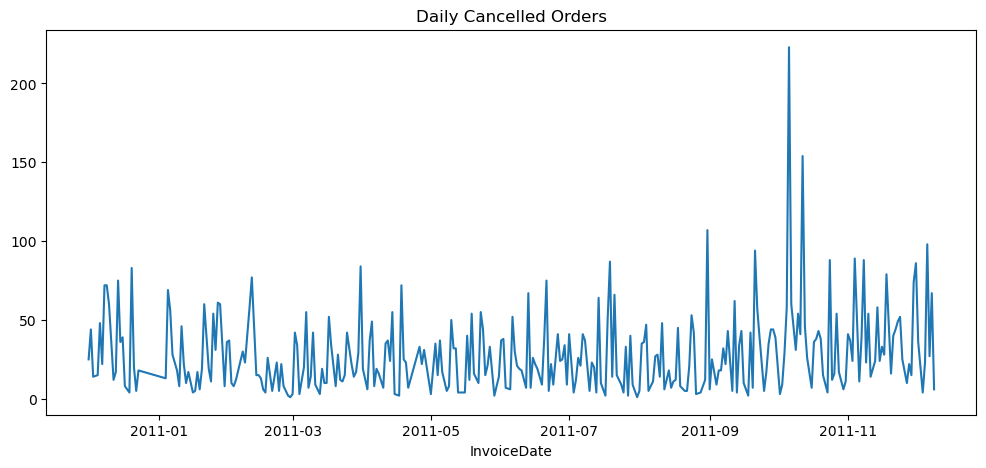

In [47]:
daily_cancel = (
    cancel_product_df
    .groupby(cancel_product_df["InvoiceDate"].dt.date)
    .size()
)

plt.figure(figsize=(12,5))

daily_cancel.plot()

plt.title("Daily Cancelled Orders")

plt.show()

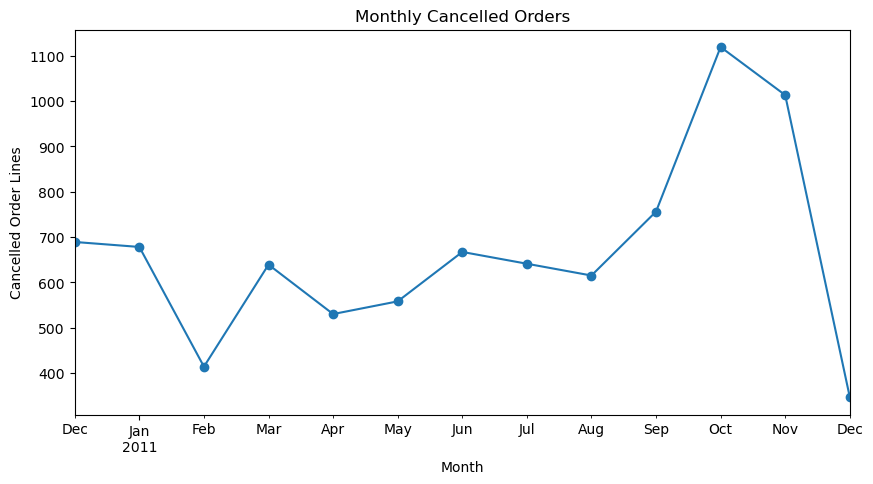

In [50]:
monthly_cancel = (
    cancel_product_df
    .groupby(cancel_product_df["InvoiceDate"].dt.to_period("M"))
    .size()
)

monthly_cancel.plot(figsize=(10,5), marker="o")

plt.title("Monthly Cancelled Orders")
plt.xlabel("Month")
plt.ylabel("Cancelled Order Lines")

plt.show()

In [49]:
cancel_product_df[
    cancel_product_df["InvoiceDate"].dt.date == pd.to_datetime("2011-10-12").date()
]["CustomerID"].value_counts().head(10)

CustomerID
12607    101
14911     43
17017      5
15473      3
12471      1
12457      1
Name: count, dtype: Int64

In [52]:
cancel_product_df[
    cancel_product_df["InvoiceDate"].dt.date == pd.to_datetime("2011-10-12").date()
]["Description"].value_counts().sort_values(ascending=False).head(20)

Description
PAPER CHAIN KIT 50'S CHRISTMAS         2
GREEN PAIR HEART HAIR SLIDES           1
GREEN ENAMEL FLOWER HAIR TIE           1
DIAMANTE HAIR GRIP PACK/2 BLACK DIA    1
DIAMANTE HAIR GRIP PACK/2 CRYSTAL      1
EDWARDIAN DROP EARRINGS JET BLACK      1
SILVER BLACK ORBIT DROP EARRINGS       1
SILVER M.O.P ORBIT DROP EARRINGS       1
MIDNIGHT BLUE VINTAGE EARRINGS         1
CRYSTAL PAIR HEART HAIR SLIDES         1
CARD CHRISTMAS VILLAGE                 1
MIDNIGHT BLUE PAIR HEART HAIR SLIDE    1
ROSE COLOUR PAIR HEART HAIR SLIDES     1
PINK ENAMEL+GLASS HAIR COMB            1
PURPLE ENAMEL+GLASS HAIR COMB          1
PAIR OF PINK FLOWER CLUSTER SLIDE      1
PAIR OF ENAMEL BUTTERFLY HAIRCLIP      1
PINK ENAMEL FLOWER HAIR TIE            1
DIAMANTE HAIR GRIP PACK/2 LT ROSE      1
WHITE ENAMEL FLOWER HAIR TIE           1
Name: count, dtype: int64

In [53]:
cancel_product_df[
    cancel_product_df["InvoiceDate"].dt.date == pd.to_datetime("2011-10-12").date()
]["Country"].value_counts()

Country
USA               101
EIRE               43
United Kingdom      8
Germany             1
Switzerland         1
Name: count, dtype: int64